# Proyecto 2
## Análisis Exploratorio de Datos (EDA)

El análisis se organiza en:
- **a.** Descripción general: número de variables, observaciones y tipos.
- **b.** Resumen de variables numéricas y tablas de frecuencia de variables categóricas.
- **c.** Cruce de las variables más relevantes para entender el problema.
- **d.** Gráficos exploratorios.

---
## 1. Importación de librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


Se encontró que la columna 'Misconception' usa el string 'NA' como una categoría válida por lo que no se puede tratar como un valor faltante

In [3]:
train = pd.read_csv('./data/train_clean.csv', keep_default_na=False, na_values=[''])
test  = pd.read_csv('./data/test.csv')

print(f'train_clean: {train.shape[0]:,} filas x {train.shape[1]} columnas')
print(f'test: {test.shape[0]:,} filas x {test.shape[1]} columnas')

train_clean: 36,696 filas x 8 columnas
test: 3 filas x 5 columnas


---
## 2. a) Descripción general de los datos

In [6]:
n_obs, n_vars = train.shape
print(f'Número de observaciones: {n_obs:,}')
print(f'Número de variables: {n_vars}')
print()
print('Tipo de dato por variable (dtype de pandas):')
print(train.dtypes)

Número de observaciones: 36,696
Número de variables: 8

Tipo de dato por variable (dtype de pandas):
row_id                 int64
QuestionId             int64
QuestionText          object
MC_Answer             object
StudentExplanation    object
Category              object
Misconception         object
short_explanation       bool
dtype: object


**Descripción de cada variable**:

| Variable | dtype pandas | Tipo de variable | Descripción |
|---|---|---|---|
| `row_id` | int64 | Identificador (no analítico) | Consecutivo único de la fila |
| `QuestionId` | int64 | Categórica nominal (codificada como número) | Identifica la pregunta de diagnóstico y solo hay 15 valores posibles |
| `QuestionText` | object (texto) | Texto libre / categórica de alta cardinalidad | Enunciado de la pregunta |
| `MC_Answer` | object (texto) | Categórica | Respuesta de opción múltiple elegida por el estudiante |
| `StudentExplanation` | object (texto) | Texto libre | Justificación escrita por el estudiante (variable central del NLP) |
| `Category` | object (texto) | Categórica nominal y variable objetivo primaria | Corrección + tipo de error (6 categorías) |
| `Misconception` | object (texto) | Categórica nominal y variable objetivo secundaria | Idea errónea específica; `'NA'` cuando no aplica |
| `short_explanation` | bool | Categórica binaria | `True` si la explicación tiene ≤5 caracteres |

Dado que es un dataset predominantemente textual y categórico, se observa que de las 8 columnas, solo `row_id` y `QuestionId` son numéricas en sentido estricto y ninguna de las dos es realmente continua. Por esto, se construyen variables numéricas derivadas del texto, usando las longitudes, para poder aplicar un resumen numérico significativo.

In [7]:
print('Observaciones únicas por variable:')
print(train.nunique().sort_values(ascending=False))
print()
print('Valores nulos por columna:')
print(train.isna().sum())

Observaciones únicas por variable:
row_id                36696
StudentExplanation    35726
MC_Answer                49
Misconception            35
QuestionText             15
QuestionId               15
Category                  6
short_explanation         2
dtype: int64

Valores nulos por columna:
row_id                0
QuestionId            0
QuestionText          0
MC_Answer             0
StudentExplanation    0
Category              0
Misconception         0
short_explanation     0
dtype: int64


No hay valores nulos reales, ya que se resolvió el caso de `Misconception` al leer los datos correctamente.

---
## 3. b) Resumen de variables numéricas y tablas de frecuencia

### 3.1 Variables numéricas derivadas
Dado que las variables numéricas nativas son identificadores, se crean variables numéricas con contenido analítico útil, usando longitudes de texto (en caracteres y en palabras) de la pregunta y de la explicación del estudiante.

In [9]:
train['len_question_words'] = train['QuestionText'].str.split().str.len()
train['len_question_chars'] = train['QuestionText'].str.len()
train['len_explanation_words'] = train['StudentExplanation'].str.split().str.len()
train['len_explanation_chars'] = train['StudentExplanation'].str.len()
train['len_answer_chars'] = train['MC_Answer'].str.len()

num_cols = ['len_question_words','len_question_chars','len_explanation_words','len_explanation_chars','len_answer_chars']

train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
len_question_words,36696.0,18.270602,12.884085,3.0,6.0,13.0,29.0,45.0
len_question_chars,36696.0,97.786734,66.218822,29.0,36.0,62.0,160.0,226.0
len_explanation_words,36696.0,15.357832,8.121211,1.0,10.0,13.0,19.0,177.0
len_explanation_chars,36696.0,70.000136,38.695576,1.0,43.0,60.0,86.0,586.0
len_answer_chars,36696.0,12.856170,6.569877,6.0,8.0,9.0,18.0,36.0


**Hallazgos del resumen**
- La explicación típica del estudiante tiene una mediana de 13 palabras (rango intercuartil 10–19), esto significa respuestas cortas y directas, propias del contexto de un examen de matemáticas.
- Existen explicaciones muy largas con un máximo de más de 170 palabras que se alejan bastante del resto. Son casos atípicos que conviene revisar antes de vectorizar el texto.
- El texto de las preguntas (`QuestionText`) tiene una dispersión alta (std ≈ 13 palabras) porque solo hay 15 preguntas distintas que se repiten para todas las filas y su longitud realmente depende del enunciado de cada pregunta, no de variabilidad fila a fila.
- `len_answer_chars` es muy pequeño y estable por lo que las respuestas son casi siempre una fracción corta en notación LaTeX.

In [10]:
# Distribución de longitud de explicación por percentiles, para fijar posibles cortes/outliers
train['len_explanation_words'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])

count    36696.000000
mean        15.357832
std          8.121211
min          1.000000
1%           6.000000
5%           6.000000
25%         10.000000
50%         13.000000
75%         19.000000
95%         31.000000
99%         43.000000
max        177.000000
Name: len_explanation_words, dtype: float64

### 3.2 Tablas de frecuencia de variables categóricas

In [11]:
freq_cat = train['Category'].value_counts()
freq_cat_pct = train['Category'].value_counts(normalize=True).mul(100).round(2)
pd.DataFrame({'Frecuencia': freq_cat, 'Porcentaje (%)': freq_cat_pct})

,Frecuencia,Porcentaje (%)
Category,,
True_Correct,14802,40.34
False_Misconception,9457,25.77
False_Neither,6542,17.83
True_Neither,5265,14.35
True_Misconception,403,1.10
False_Correct,227,0.62


`Category` (variable objetivo primaria): el dataset está fuertemente desbalanceado. `True_Correct` concentra ~40% de las filas, mientras que `True_Misconception` y `False_Correct` (respuesta correcta obtenida con un razonamiento erróneo) representan apenas ~1% y ~0.6% respectivamente. Un modelo de clasificación entrenado sin ajustar por este desbalance tenderá a favorecer las clases mayoritarias.

In [12]:
freq_misc = train.loc[train['Misconception'] != 'NA', 'Misconception'].value_counts()
freq_misc_pct = (freq_misc / freq_misc.sum() * 100).round(2)
tabla_misc = pd.DataFrame({'Frecuencia': freq_misc, 'Porcentaje entre misconceptions (%)': freq_misc_pct})
print(f'Número de ideas erróneas (misconceptions) distintas: {freq_misc.shape[0]}')
tabla_misc

Número de ideas erróneas (misconceptions) distintas: 34


,Frecuencia,Porcentaje entre misconceptions (%)
Misconception,,
Incomplete,1454,14.75
Additive,929,9.42
Duplication,704,7.14
Wrong_fraction,691,7.01
Subtraction,620,6.29
Positive,566,5.74
Wrong_term,558,5.66
Irrelevant,497,5.04
Inversion,414,4.20


`Misconception` (excluyendo `'NA'`): hay 34 ideas erróneas distintas, pero su frecuencia también es muy desigual. `Incomplete` (razonamiento incompleto) es por mucho, la más común con ~10.9% de los casos con misconception, seguida de `Additive` y `Duplication`. Casi la mitad de las categorías tiene menos de 100 observaciones, lo cual aumenta la dificultad para clasificarlas, ya que hay muy pocos ejemplos de entrenamiento por clase minoritaria.

In [13]:
freq_qid = train['QuestionId'].value_counts().sort_index()
pd.DataFrame({'Frecuencia': freq_qid, 'Porcentaje (%)': (freq_qid/freq_qid.sum()*100).round(2)})

,Frecuencia,Porcentaje (%)
QuestionId,,
31772,4857,13.24
31774,3115,8.49
31777,2809,7.65
31778,3640,9.92
32829,2156,5.88
32833,3105,8.46
32835,2332,6.35
33471,1542,4.20
33472,2800,7.63


`QuestionId`: hay 15 preguntas de diagnóstico distintas. La cantidad de respuestas por pregunta oscila, lo que indica que no todas las preguntas fueron respondidas por el mismo número de estudiantes; algunas preguntas aportan bastante más señal al dataset que otras.

In [14]:
freq_short = train['short_explanation'].value_counts()
print(freq_short)
print()
top_answers = train['MC_Answer'].value_counts().head(10)
print('Top 10 respuestas de opción múltiple más frecuentes:')
print(top_answers)

short_explanation
False    36684
True        12
Name: count, dtype: int64

Top 10 respuestas de opción múltiple más frecuentes:
MC_Answer
\( \frac{1}{3} \)      2599
\( 6 \)                2368
\( \frac{3}{9} \)      1979
\( \frac{1}{12} \)     1918
\( 72 \)               1798
\( 3 \)                1792
\( 12 \)               1716
\( 6.2 \)              1674
\( \frac{11}{15} \)    1651
\( 3 \frac{1}{3} \)    1601
Name: count, dtype: int64


**`short_explanation`:** solo 12 filas (0.03%) tienen explicaciones extremadamente cortas, confirmando la conclusión del notebook de limpieza que no es un problema masivo, sino casos puntuales ya marcados.

**`MC_Answer`:** al ser texto en formato LaTeX, cada pregunta tiene sus propias opciones; por eso las respuestas más frecuentes están dominadas por las fracciones asociadas a las preguntas con más observaciones.

---
## 4. c) Cruce de variables clave

El problema central de este dataset es clasificar correctamente la combinación `Category` + `Misconception` a partir del texto. Por eso los cruces se enfocan en entender qué combinación de pregunta, corrección y longitud de texto está asociada a la aparición de ideas erróneas, que es la señal más difícil de capturar y la más desbalanceada.

### 4.1 `Category` × `QuestionId` — ¿todas las preguntas generan el mismo tipo de error?

In [15]:
ct_cat_q = pd.crosstab(train['QuestionId'], train['Category'])
ct_cat_q_pct = pd.crosstab(train['QuestionId'], train['Category'], normalize='index').mul(100).round(1)
ct_cat_q

Category,False_Correct,False_Misconception,False_Neither,True_Correct,True_Misconception,True_Neither
QuestionId,,,,,,
31772,31,1605,873,1719,16,613
31774,19,617,561,1405,20,493
31777,35,390,586,1628,0,170
31778,19,1296,564,1140,126,495
32829,9,271,160,1580,1,135
32833,9,1113,382,1235,11,355
32835,16,380,262,954,19,701
33471,16,431,221,701,6,167
33472,47,645,457,1014,7,630


In [16]:
ct_cat_q_pct

Category,False_Correct,False_Misconception,False_Neither,True_Correct,True_Misconception,True_Neither
QuestionId,,,,,,
31772,0.6,33.0,18.0,35.4,0.3,12.6
31774,0.6,19.8,18.0,45.1,0.6,15.8
31777,1.2,13.9,20.9,58.0,0.0,6.1
31778,0.5,35.6,15.5,31.3,3.5,13.6
32829,0.4,12.6,7.4,73.3,0.0,6.3
32833,0.3,35.8,12.3,39.8,0.4,11.4
32835,0.7,16.3,11.2,40.9,0.8,30.1
33471,1.0,28.0,14.3,45.5,0.4,10.8
33472,1.7,23.0,16.3,36.2,0.2,22.5


Se observa que el porcentaje de `True_Misconception`, `False_Misconception` y `False_Neither` varía notablemente entre preguntas, esto muestra que hay preguntas donde más del 30–40% de las respuestas caen en alguna categoría de error, y otras donde predominan ampliamente las respuestas correctas. 


Esto sugiere que la dificultad conceptual no está distribuida de forma uniforme entre las preguntas y por ende, algunas preguntas de fracciones "atrapan" mucho más a los estudiantes que otras y el modelo probablemente deba apoyarse fuertemente en `QuestionId`/`QuestionText` como variable de contexto.

### 4.2 `Misconception` × `QuestionId` — ¿las ideas erróneas son específicas de cada pregunta?

In [17]:
solo_con_misc = train[train['Misconception'] != 'NA']
ct_misc_q = pd.crosstab(solo_con_misc['QuestionId'], solo_con_misc['Misconception'])

# Para cada pregunta, la idea errónea más frecuente
misc_dominante = ct_misc_q.idxmax(axis=1)
freq_dominante = ct_misc_q.max(axis=1)
resumen = pd.DataFrame({'Misconception más frecuente': misc_dominante,
                         'Frecuencia': freq_dominante,
                         'Total misconceptions en la pregunta': ct_misc_q.sum(axis=1)})
resumen

,Misconception más frecuente,Frecuencia,Total misconceptions en la pregunta
QuestionId,,,
31772,Incomplete,1359,1621
31774,Mult,353,637
31777,Wrong_fraction,273,390
31778,Additive,929,1422
32829,Not_variable,154,272
32833,Duplication,704,1124
32835,Whole_numbers_larger,329,399
33471,Wrong_fraction,418,437
33472,Denominator-only_change,336,652


Cada pregunta tiene una idea errónea dominante muy marcada como por ejemplo, `Incomplete` domina en varias preguntas de figuras sombreadas, mientras `Additive` o `Duplication` dominan en preguntas de suma/comparación de fracciones. Esto confirma que `Misconception` depende fuertemente del contenido matemático específico de la pregunta, no es un patrón textual genérico y un mismo error de razonamiento se manifiesta con palabras distintas según la pregunta.

### 4.3 Longitud de la explicación vs. corrección y presencia de misconception

In [18]:
train['is_correct'] = train['Category'].str.startswith('True')
train['has_misconception'] = train['Misconception'] != 'NA'

resumen_long = train.groupby('Category')['len_explanation_words'].agg(['count','mean','median','std']).round(2)
resumen_long

,count,mean,median,std
Category,,,,
False_Correct,227,18.55,17.0,8.23
False_Misconception,9457,14.80,13.0,6.86
False_Neither,6542,12.74,11.0,6.53
True_Correct,14802,17.62,16.0,9.03
True_Misconception,403,16.40,15.0,8.90
True_Neither,5265,13.04,11.0,7.38


In [19]:
resumen_long2 = train.groupby('has_misconception')['len_explanation_words'].agg(['count','mean','median','std']).round(2)
resumen_long2

,count,mean,median,std
has_misconception,,,,
False,26836,15.54,13.0,8.50
True,9860,14.87,13.0,6.97


Las explicaciones de las filas con `Misconception` presente tienden a ser un poco más largas en promedio que las que no la tienen y las categorías `*_Neither` tienden a mostrar explicaciones más cortas o más ambiguas. Esto es coherente con la intuición que cuando el estudiante articula un razonamiento erróneo concreto, suele explicarlo con más palabras que cuando simplemente acierta o da una respuesta vaga.

### 4.4 Correlación entre variables numéricas derivadas

In [20]:
corr = train[['len_question_words','len_question_chars','len_explanation_words',
              'len_explanation_chars','len_answer_chars']].corr()
corr

,len_question_words,len_question_chars,len_explanation_words,len_explanation_chars,len_answer_chars
len_question_words,1.000000,0.987192,-0.031702,-0.046046,0.084726
len_question_chars,0.987192,1.000000,-0.033905,-0.038050,0.150343
len_explanation_words,-0.031702,-0.033905,1.000000,0.962926,0.061552
len_explanation_chars,-0.046046,-0.038050,0.962926,1.000000,0.093243
len_answer_chars,0.084726,0.150343,0.061552,0.093243,1.000000


Como es de esperar, la longitud en palabras y en caracteres de un mismo texto están altamente correlacionadas entre sí (≈0.9+), por lo que para modelar basta con conservar una de las dos versiones (palabras o caracteres) de cada variable de longitud, evitando redundancia.

---
## 5. d) Gráficos exploratorios

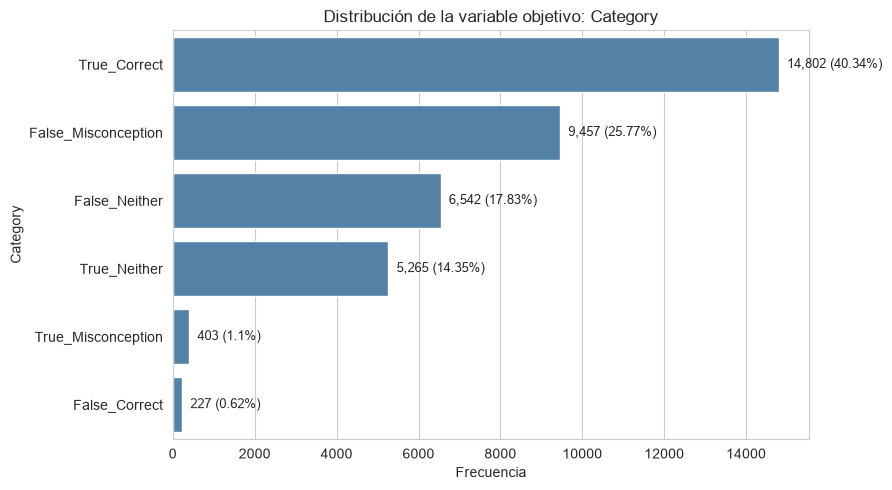

In [21]:
fig, ax = plt.subplots(figsize=(9,5))
order = freq_cat.index
sns.barplot(x=freq_cat.values, y=order, ax=ax, color='steelblue')
ax.set_xlabel('Frecuencia')
ax.set_title('Distribución de la variable objetivo: Category')
for i, v in enumerate(freq_cat.values):
    ax.text(v + 200, i, f'{v:,} ({freq_cat_pct.iloc[i]}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

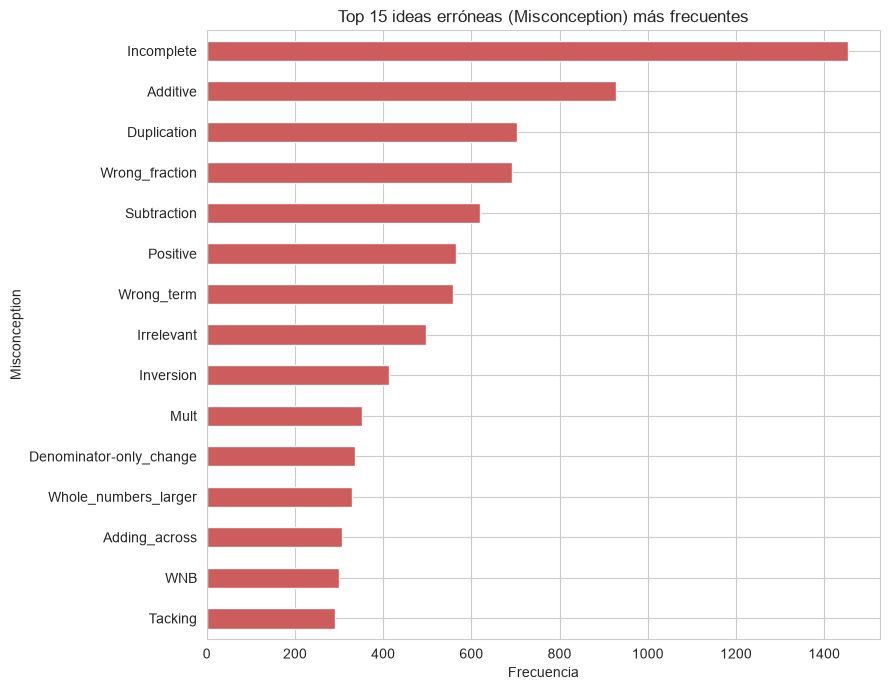

In [22]:
fig, ax = plt.subplots(figsize=(9,7))
top15 = freq_misc.head(15).sort_values()
top15.plot(kind='barh', ax=ax, color='indianred')
ax.set_xlabel('Frecuencia')
ax.set_title('Top 15 ideas erróneas (Misconception) más frecuentes')
plt.tight_layout()
plt.show()

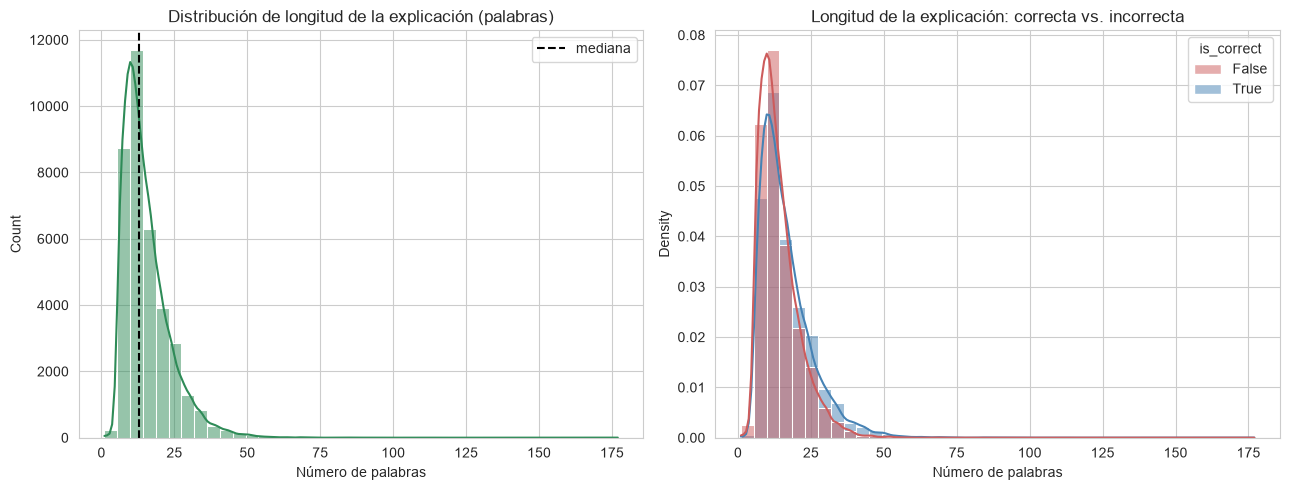

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(train['len_explanation_words'], bins=40, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Distribución de longitud de la explicación (palabras)')
axes[0].set_xlabel('Número de palabras')
axes[0].axvline(train['len_explanation_words'].median(), color='black', linestyle='--', label='mediana')
axes[0].legend()

sns.histplot(data=train, x='len_explanation_words', hue='is_correct', bins=40,
             kde=True, ax=axes[1], stat='density', common_norm=False, palette=['indianred','steelblue'])
axes[1].set_title('Longitud de la explicación: correcta vs. incorrecta')
axes[1].set_xlabel('Número de palabras')
plt.tight_layout()
plt.show()

La distribución de longitud está sesgada a la derecha. Al separar por corrección, las distribuciones se superponen bastante y la longitud por sí sola no separa claramente respuestas correctas de incorrectas, lo que refuerza que el reto de este problema está en el contenido semántico del texto, no en atributos superficiales como el largo.

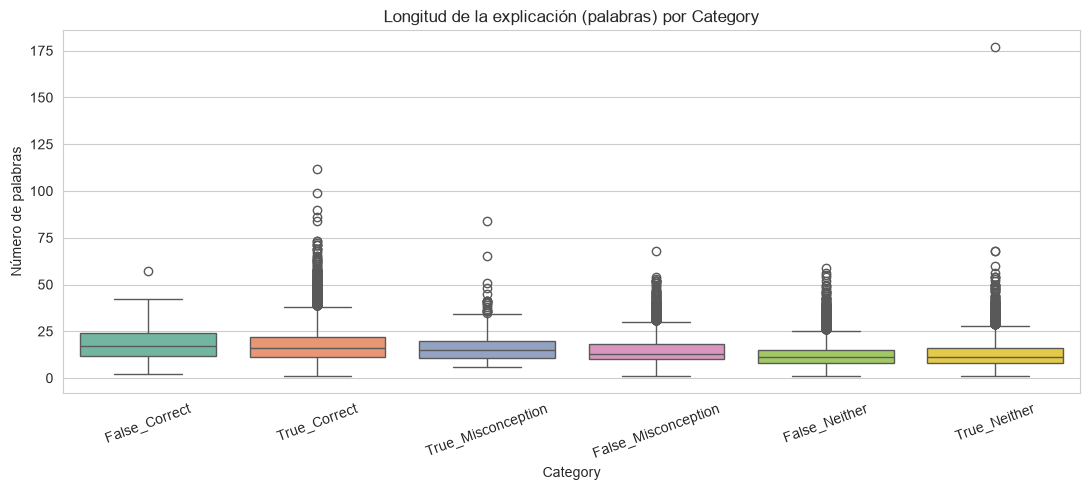

In [24]:
fig, ax = plt.subplots(figsize=(11,5))
order_cat = train.groupby('Category')['len_explanation_words'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='Category', y='len_explanation_words', order=order_cat, ax=ax, palette='Set2')
ax.set_title('Longitud de la explicación (palabras) por Category')
ax.set_ylabel('Número de palabras')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

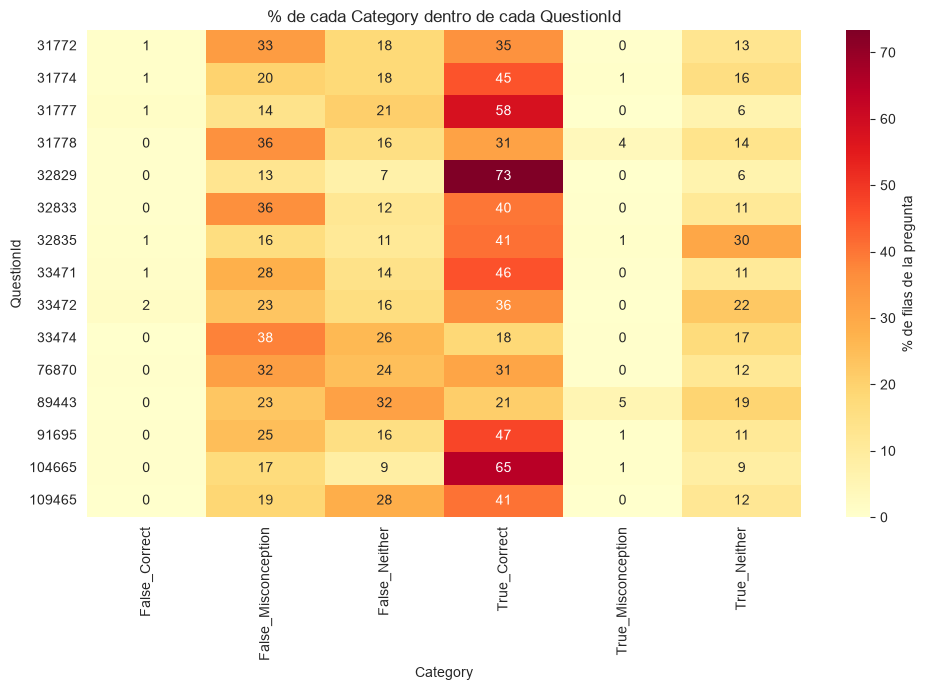

In [25]:
fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(ct_cat_q_pct, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': '% de filas de la pregunta'}, ax=ax)
ax.set_title('% de cada Category dentro de cada QuestionId')
ax.set_xlabel('Category')
ax.set_ylabel('QuestionId')
plt.tight_layout()
plt.show()

Este mapa de calor muestra claramente que hay preguntas "difíciles" donde hay filas con manchas cálidas en las columnas de error, frente a preguntas "fáciles" con las filas dominadas por `True_Correct`. Cualquier estrategia de modelado debería considerar `QuestionId` como una señal fuerte, por ejemplo como feature categórica adicional al texto.

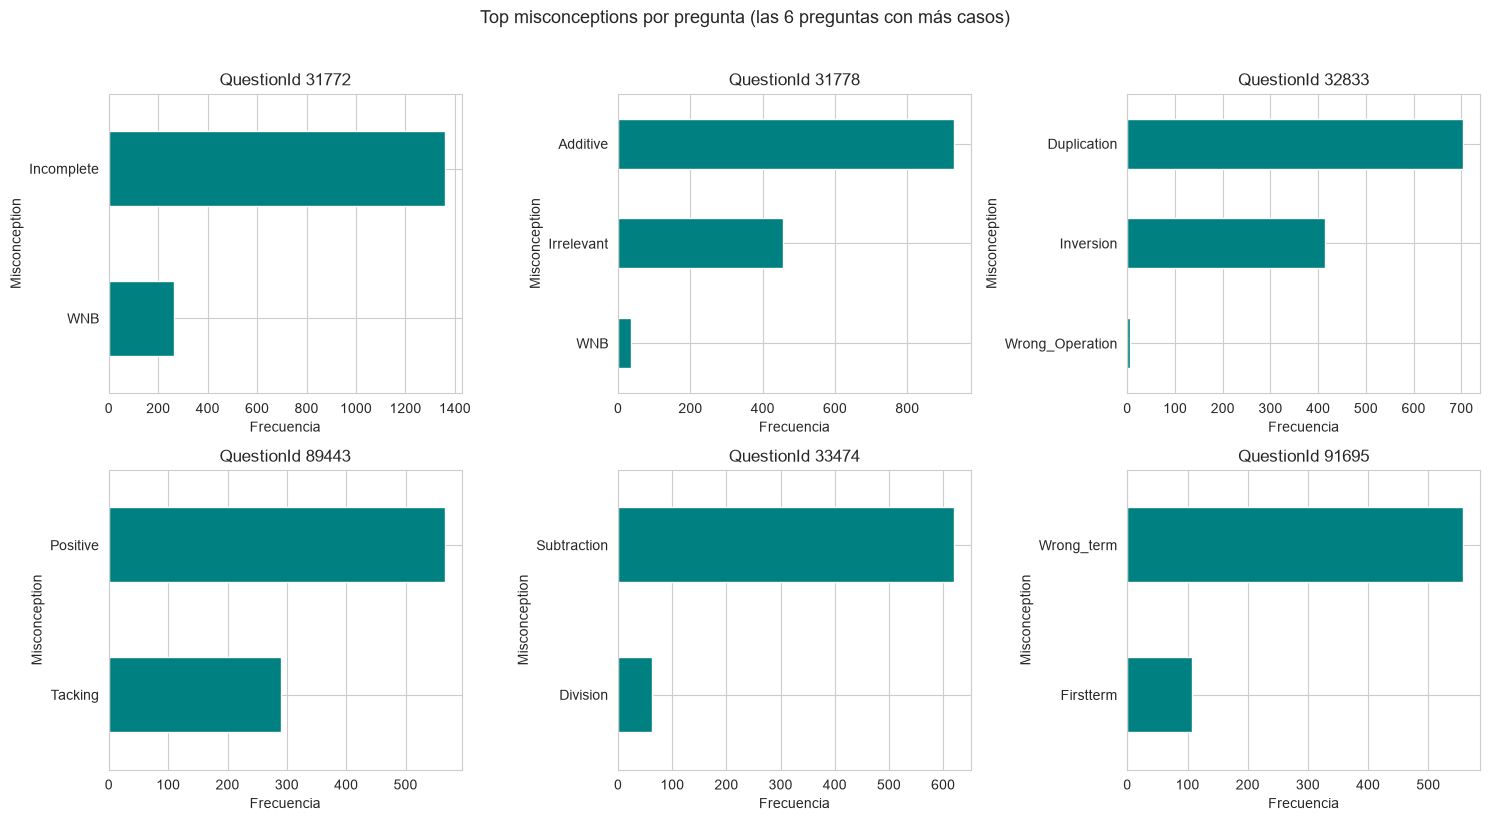

In [26]:
# Top 3 misconceptions por pregunta
top_qs = solo_con_misc['QuestionId'].value_counts().head(6).index
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()
for i, q in enumerate(top_qs):
    sub = solo_con_misc[solo_con_misc['QuestionId']==q]['Misconception'].value_counts().head(5).sort_values()
    sub.plot(kind='barh', ax=axes[i], color='teal')
    axes[i].set_title(f'QuestionId {q}')
    axes[i].set_xlabel('Frecuencia')
plt.suptitle('Top misconceptions por pregunta (las 6 preguntas con más casos)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Se confirma visualmente lo encontrado en la sección (c) donde cada pregunta tiene un "perfil" propio de errores, con una o dos ideas erróneas que concentran la mayoría de los casos, esto da información valiosa si se plantea un modelo jerárquico para primero predecir `Category` y solo si corresponde a una clase con error, predecir `Misconception` condicionado a la pregunta.

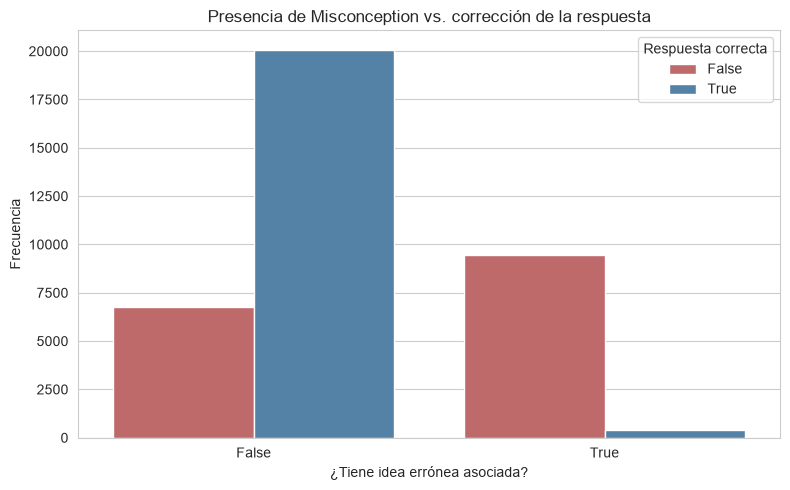

In [27]:
fig, ax = plt.subplots(figsize=(8,5))
sns.countplot(data=train, x='has_misconception', hue='is_correct', palette=['indianred','steelblue'], ax=ax)
ax.set_title('Presencia de Misconception vs. corrección de la respuesta')
ax.set_xlabel('¿Tiene idea errónea asociada?')
ax.set_ylabel('Frecuencia')
ax.legend(title='Respuesta correcta')
plt.tight_layout()
plt.show()

Este último gráfico resume el "problema" que hay que resolver con NLP: existen respuestas correctas con una idea errónea de fondo mostrando que el estudiante llegó bien mezclando conceptos mal entendidos y respuestas incorrectas sin una idea errónea identificable (`*_Neither`). Distinguir estos casos requiere entender el razonamiento expresado en el texto, no solo si la respuesta final fue correcta.

---
## 6. Conclusiones del EDA

1. **Dataset predominantemente textual/categórico:** de 8 variables, ninguna es numérica continua "real"; el resumen numérico se construyó sobre variables derivadas de longitud de texto, que además están altamente correlacionadas entre sí (caracteres vs. palabras).

2. **Fuerte desbalance de clases** en ambas variables objetivo, `Category` está dominada por `True_Correct` (~40%), y dentro de `Misconception` (34 clases), varias tienen menos de 100 observaciones. Cualquier modelo deberá manejar este desbalance con ponderación de clases, estratificación y métricas robustas a clases minoritarias.

3. **Las preguntas (`QuestionId`) no son intercambiables:** el porcentaje de respuestas correctas/incorrectas y el tipo de idea errónea dominante varían mucho de una pregunta a otra. `QuestionId`/`QuestionText` debe tratarse como señal de contexto relevante, no solo como metadato.

4. **Cada `Misconception` está asociada a preguntas específicas:** las ideas erróneas no son un fenómeno textual genérico, sino ligadas al contenido matemático concreto de cada pregunta por lo que se sugiere modelar `Misconception` de forma condicionada a la pregunta.

5. **La longitud del texto no discrimina por sí sola** correcto vs. incorrecto ni presencia vs. ausencia de misconception; el reto de clasificación recae en el contenido semántico de `StudentExplanation`, reforzando la necesidad de un enfoque de NLP más que de variables superficiales.

6. **Recomendación de preprocesamiento adicional:** dado el punto 1, conviene revisar los outliers de explicaciones muy largas antes de vectorizar, y mantener presente el manejo especial del string `'NA'` en `Misconception` en cualquier paso posterior.